In [22]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score




In [2]:
x_train=np.linspace(-1, 1 ,20)
x_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415, 0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])
y_train.shape

(20,)

In [4]:
x_test=np.linspace(-1, 1, 20)
x_test

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [5]:
y_test=y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,-0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])
y_test.shape

(20,)

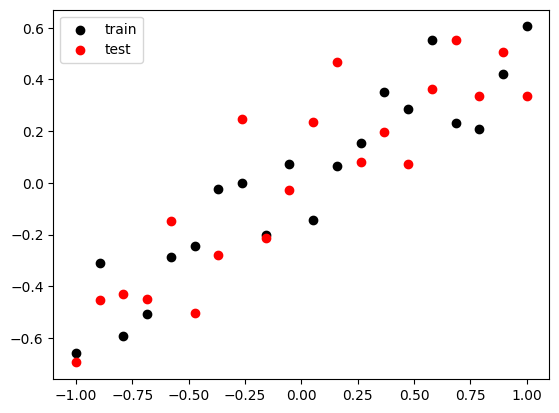

In [6]:
plt.scatter(x_train, y_train, color='black', label='train')
plt.scatter(x_test, y_test , c='red', label='test')
plt.legend()
plt.show()

In [7]:
model=Sequential()
model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dense(128, activation='relu'))
'''model.add(Dense(32, activation='relu'))'''
model.add(Dense(1, activation='linear'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])
history=model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=False)
history


In [13]:
_, train_mse=model.evaluate(x_train, y_train, verbose=0)
_, test_mse=model.evaluate(x_test, y_test, verbose=0)
print('Train MSE: %.3f, Test MSE: %.3f' % (train_mse, test_mse))

Train MSE: 0.017, Test MSE: 0.034


In [14]:
y_pred=model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


array([[-0.502004  ],
       [-0.43801728],
       [-0.37403053],
       [-0.31009978],
       [-0.24641892],
       [-0.18330449],
       [-0.12553342],
       [-0.0864853 ],
       [-0.06076019],
       [-0.04039092],
       [-0.02106002],
       [ 0.07206257],
       [ 0.18143767],
       [ 0.2512151 ],
       [ 0.2977674 ],
       [ 0.34238827],
       [ 0.38594237],
       [ 0.42909658],
       [ 0.47224978],
       [ 0.51541495]], dtype=float32)

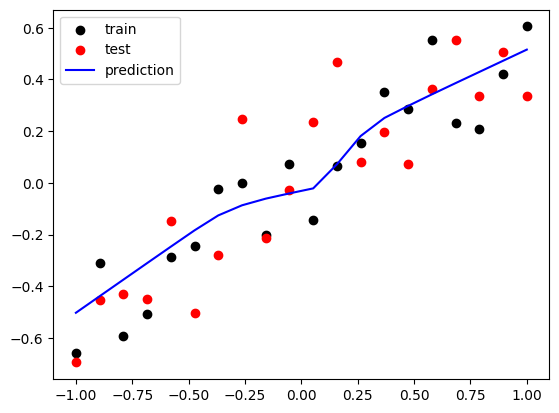

In [15]:
plt.scatter(x_train, y_train, color='black', label='train')
plt.scatter(x_test, y_test , c='red', label='test')
plt.plot(x_test, y_pred, color='blue', label='prediction')
plt.legend()
plt.show()

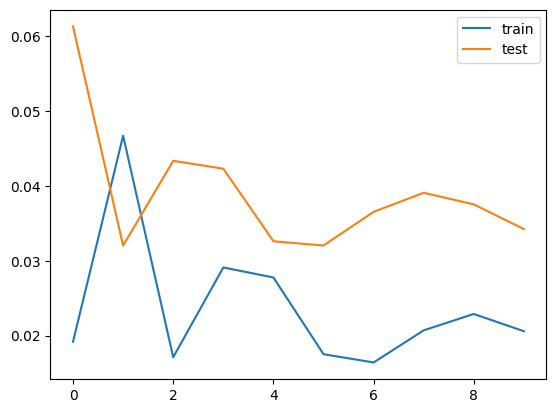

In [16]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

 History <keras.src.callbacks.history.History object at 0x7babd423e1b0>
Train MSE: 0.004, Test MSE: 0.045
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
 prediction_data  [[-5.4514903e-01]
 [-5.2331662e-01]
 [-5.0148439e-01]
 [-4.7608808e-01]
 [-3.4218517e-01]
 [-2.0738338e-01]
 [-3.1886101e-02]
 [ 2.9599667e-04]
 [-1.9976605e-01]
 [ 7.6135814e-02]
 [-1.2649396e-01]
 [ 3.5975710e-02]
 [ 1.7307058e-01]
 [ 3.3882657e-01]
 [ 3.4234741e-01]
 [ 4.6042213e-01]
 [ 2.5592941e-01]
 [ 2.0932820e-01]
 [ 4.0708324e-01]
 [ 6.0483813e-01]]


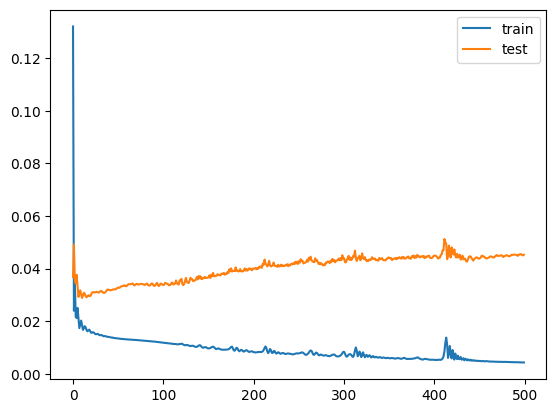

In [17]:
model=Sequential()
model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dense(128, activation='relu'))
'''model.add(Dense(32, activation='relu'))'''
model.add(Dense(1, activation='linear'))
model.summary()
adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])
history=model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=False)
print(' History',history)
_, train_mse=model.evaluate(x_train, y_train, verbose=0)
_, test_mse=model.evaluate(x_test, y_test, verbose=0)
print('Train MSE: %.3f, Test MSE: %.3f' % (train_mse, test_mse))
y_pred=model.predict(x_test)
print(" prediction_data ",y_pred)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [25]:
r2_score(y_test, y_pred)

0.7193091554434787

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

 History <keras.src.callbacks.history.History object at 0x7babb6f556a0>
Train MSE: 0.012, Test MSE: 0.039
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
 prediction_data  [[-0.6169231 ]
 [-0.55005443]
 [-0.48466778]
 [-0.4176666 ]
 [-0.3472188 ]
 [-0.26570636]
 [-0.1247853 ]
 [-0.09416559]
 [-0.09100756]
 [-0.07550306]
 [-0.05825706]
 [ 0.00953635]
 [ 0.18171455]
 [ 0.28138503]
 [ 0.33018902]
 [ 0.3369308 ]
 [ 0.3426564 ]
 [ 0.36757025]
 [ 0.48767924]
 [ 0.61893696]]


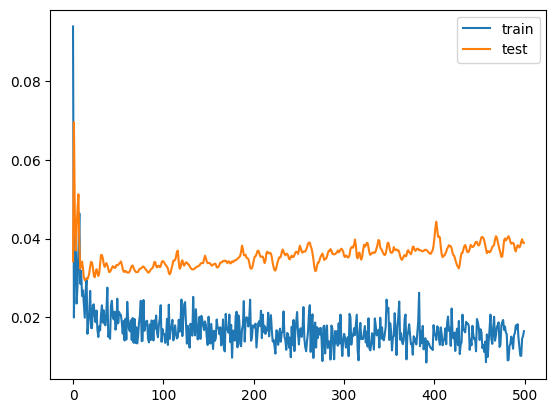

In [19]:
model=Sequential()

model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

'''model.add(Dense(32, activation='relu'))'''

model.add(Dense(1, activation='linear'))

model.summary()

adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history=model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=False)
print(' History',history)

_, train_mse=model.evaluate(x_train, y_train, verbose=0)
_, test_mse=model.evaluate(x_test, y_test, verbose=0)
print('Train MSE: %.3f, Test MSE: %.3f' % (train_mse, test_mse))

y_pred=model.predict(x_test)
print(" prediction_data ",y_pred)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

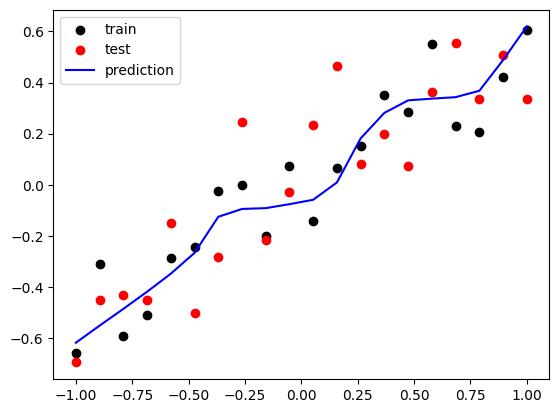

In [20]:
plt.scatter(x_train, y_train, color='black', label='train')
plt.scatter(x_test, y_test , c='red', label='test')
plt.plot(x_test, y_pred, color='blue', label='prediction')
plt.legend()
plt.show()

In [24]:
r2_score(y_test, y_pred)

0.7193091554434787